## Data Generation - Rodrigo Michelassi

This notebook is responsible for generating the data for my bachelor thesis.

We will be running a simple dataset analysis just to decide how to deal with all the data we want to train our models and generate new data from it.

In [5]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from ultralytics import YOLO
from PIL import Image

### Loading detection model

In [6]:
model_path = '/home/rodrigocm/tcc/models/optic-disc-detection.pt'
model = YOLO(model_path)

In [7]:
import sys
sys.path.append('..')

from scripts.yolo_lib import getPredictions

img_path = '/home/rodrigocm/tcc/data/test-images'

test_image = os.path.join(img_path, 'img01059.jpg')
output_image = os.path.join(img_path, 'img01059_result.jpg')

results = getPredictions(imagePath=test_image, odModel=model, saveImg=True, output_path=output_image)


image 1/1 /home/rodrigocm/tcc/data/test-images/img01059.jpg: 512x640 1 optic_disc, 9.6ms
Speed: 2.8ms preprocess, 9.6ms inference, 1.2ms postprocess per image at shape (1, 3, 512, 640)


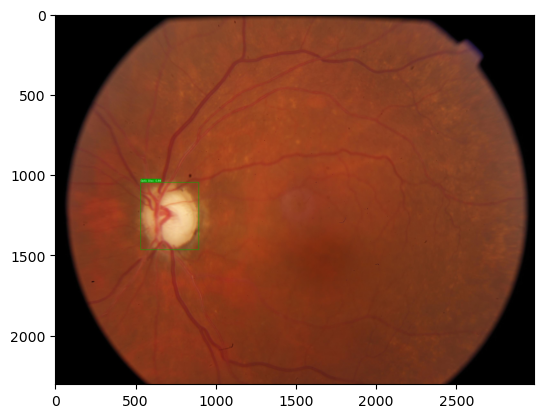

In [8]:
img = np.asarray(Image.open(output_image))
plt.imshow(img)

### Dataset Analysis

Run a simple analysis on BRSET and create a list of images that should be deleted.

For instance, images with a low number of diseases should no be a part of our final dataset.

In [9]:
brset_path = '/scratch/datasets/retina/brset'

brset_df = pd.read_csv(os.path.join(brset_path, 'labels.csv'))
brset_df.head(10)

,image_id,patient_id,camera,patient_age,comorbidities,diabetes_time_y,insuline,patient_sex,exam_eye,diabetes,...,amd,vascular_occlusion,hypertensive_retinopathy,drusens,hemorrhage,retinal_detachment,myopic_fundus,increased_cup_disc,other,quality
0,img00001,1,Canon CR,48.0,diabetes1,12,yes,1,1,yes,...,0,0,0,0,0,0,0,1,0,Adequate
1,img00002,1,Canon CR,48.0,diabetes1,12,yes,1,2,yes,...,0,0,0,0,0,0,0,1,0,Adequate
2,img00003,2,Canon CR,18.0,diabetes1,7,yes,2,1,yes,...,0,0,0,0,0,0,0,0,0,Adequate
3,img00004,2,Canon CR,18.0,diabetes1,7,yes,2,2,yes,...,0,0,0,0,0,0,0,0,0,Adequate
4,img00005,3,Canon CR,22.0,diabetes1,11,yes,1,1,yes,...,0,0,0,0,0,0,0,0,0,Adequate
5,img00006,3,Canon CR,22.0,diabetes1,11,yes,1,2,yes,...,0,0,0,0,0,0,0,0,0,Adequate
6,img00007,4,Canon CR,22.0,diabetes1,1,yes,1,1,yes,...,0,0,0,0,0,0,0,0,0,Adequate
7,img00008,4,Canon CR,22.0,diabetes1,1,yes,1,2,yes,...,0,0,0,0,0,0,0,0,0,Adequate
8,img00009,5,Canon CR,23.0,diabetes1,20,yes,1,1,yes,...,0,0,0,0,0,0,0,0,0,Adequate
9,img00010,5,Canon CR,23.0,diabetes1,20,yes,1,2,yes,...,0,0,0,0,0,0,0,0,0,Adequate


### Enrich Dataset with Detection Model

### Enrich Dataset with LLM Labels

### Save Dataset

Gets the remaining images from the dataset and their appropriate labels for CLIP and SIGLIP training to the dataset path for this project.

For CLIP and SIGLIP dataset definition, the files structure will be:

```sh
dataset/
 ├── images/
 │    ├── img1.jpg
 │    ├── img2.jpg
 │    └── ...
 └── captions.csv   (or .json / .txt)
```